# Smoke analysis — local smoke_test log

Parses plain-text stdout from `scripts/smoke_test.sh` (written to `scripts/smoke.txt`).

Layout-aware via `scripts/smoke_analysis/layout.py` (follows `main.py`: **milos** farmer-only, or `agent.zoning.CURRENT` for FIVE / TWO / THREE).

Covers hire-on-demand acceptance checks: write-on-solve, skip-not-break cascade, dawn empties (stacked land1+land2), planner zone solves (`[planner] wsp zone=…`), probe/BUY_LAND, and land2 `keep` stranding.

**Kaggle-faithful:** smokes are unseeded (env picks the seed). Compare code versions with multiple runs, not a pinned seed:

```bash
bash scripts/smoke_test.sh              # single run -> scripts/smoke.txt
SMOKE_RUNS=8 bash scripts/smoke_multi_run.sh   # distribution -> scripts/smoke_runs/
```

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "agent").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))

from smoke_analysis import (
    analyze,
    plot_earnings_by_day,
    plot_earnings_by_zone,
    plot_smoke,
    plot_stuck_skip_freq,
    plot_worker_actions,
    plot_zone_capacity,
    summarize,
    summarize_distribution,
)

SMOKE_LOG = ROOT / "scripts/smoke.txt"
print(SMOKE_LOG, SMOKE_LOG.exists())

/media/wlaki/W/DS_projects/Kaggle/kaggriculture/scripts/smoke.txt True


In [3]:
report = analyze(SMOKE_LOG)
print(summarize(report))

[zoning] CURRENT=milos_twoland12 tiles=50 hands=11
log=smoke seed=None layout=milos_farmer package=milos land2=0 workers reward=139056.0 smoke_passed=True buy_land_day=11
PASS total=1660 HIRE total=261
replan_days=21 skip_cascade=0 infeasible=0
idle: mean_empty=0.6 land2_mean=0.0 hire5_empty_days=12 max_streak=12
stuck: workers=- healed<=5d=- permanent/slow=-
  [OK] write_day0_ge1: all day0≥1 writes present
  [OK] skip_not_break: 0 post-buy skips, cascade continued
  [OK] no_dark_land2_keep: one-land layout (no land2)
  [OK] thin_writes_logged: no thin zones
  [OK] hire5_idle_proxy: one-land layout (no land2)
  [OK] missing_from_solved: no worker missing solved ≥3 replans
  [OK] stale_start_blocks: 0 start_block age≥2
  [OK] smoke_health: parsed from log


/media/wlaki/W/DS_projects/Kaggle/kaggriculture/scripts/smoke_analysis/plot.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


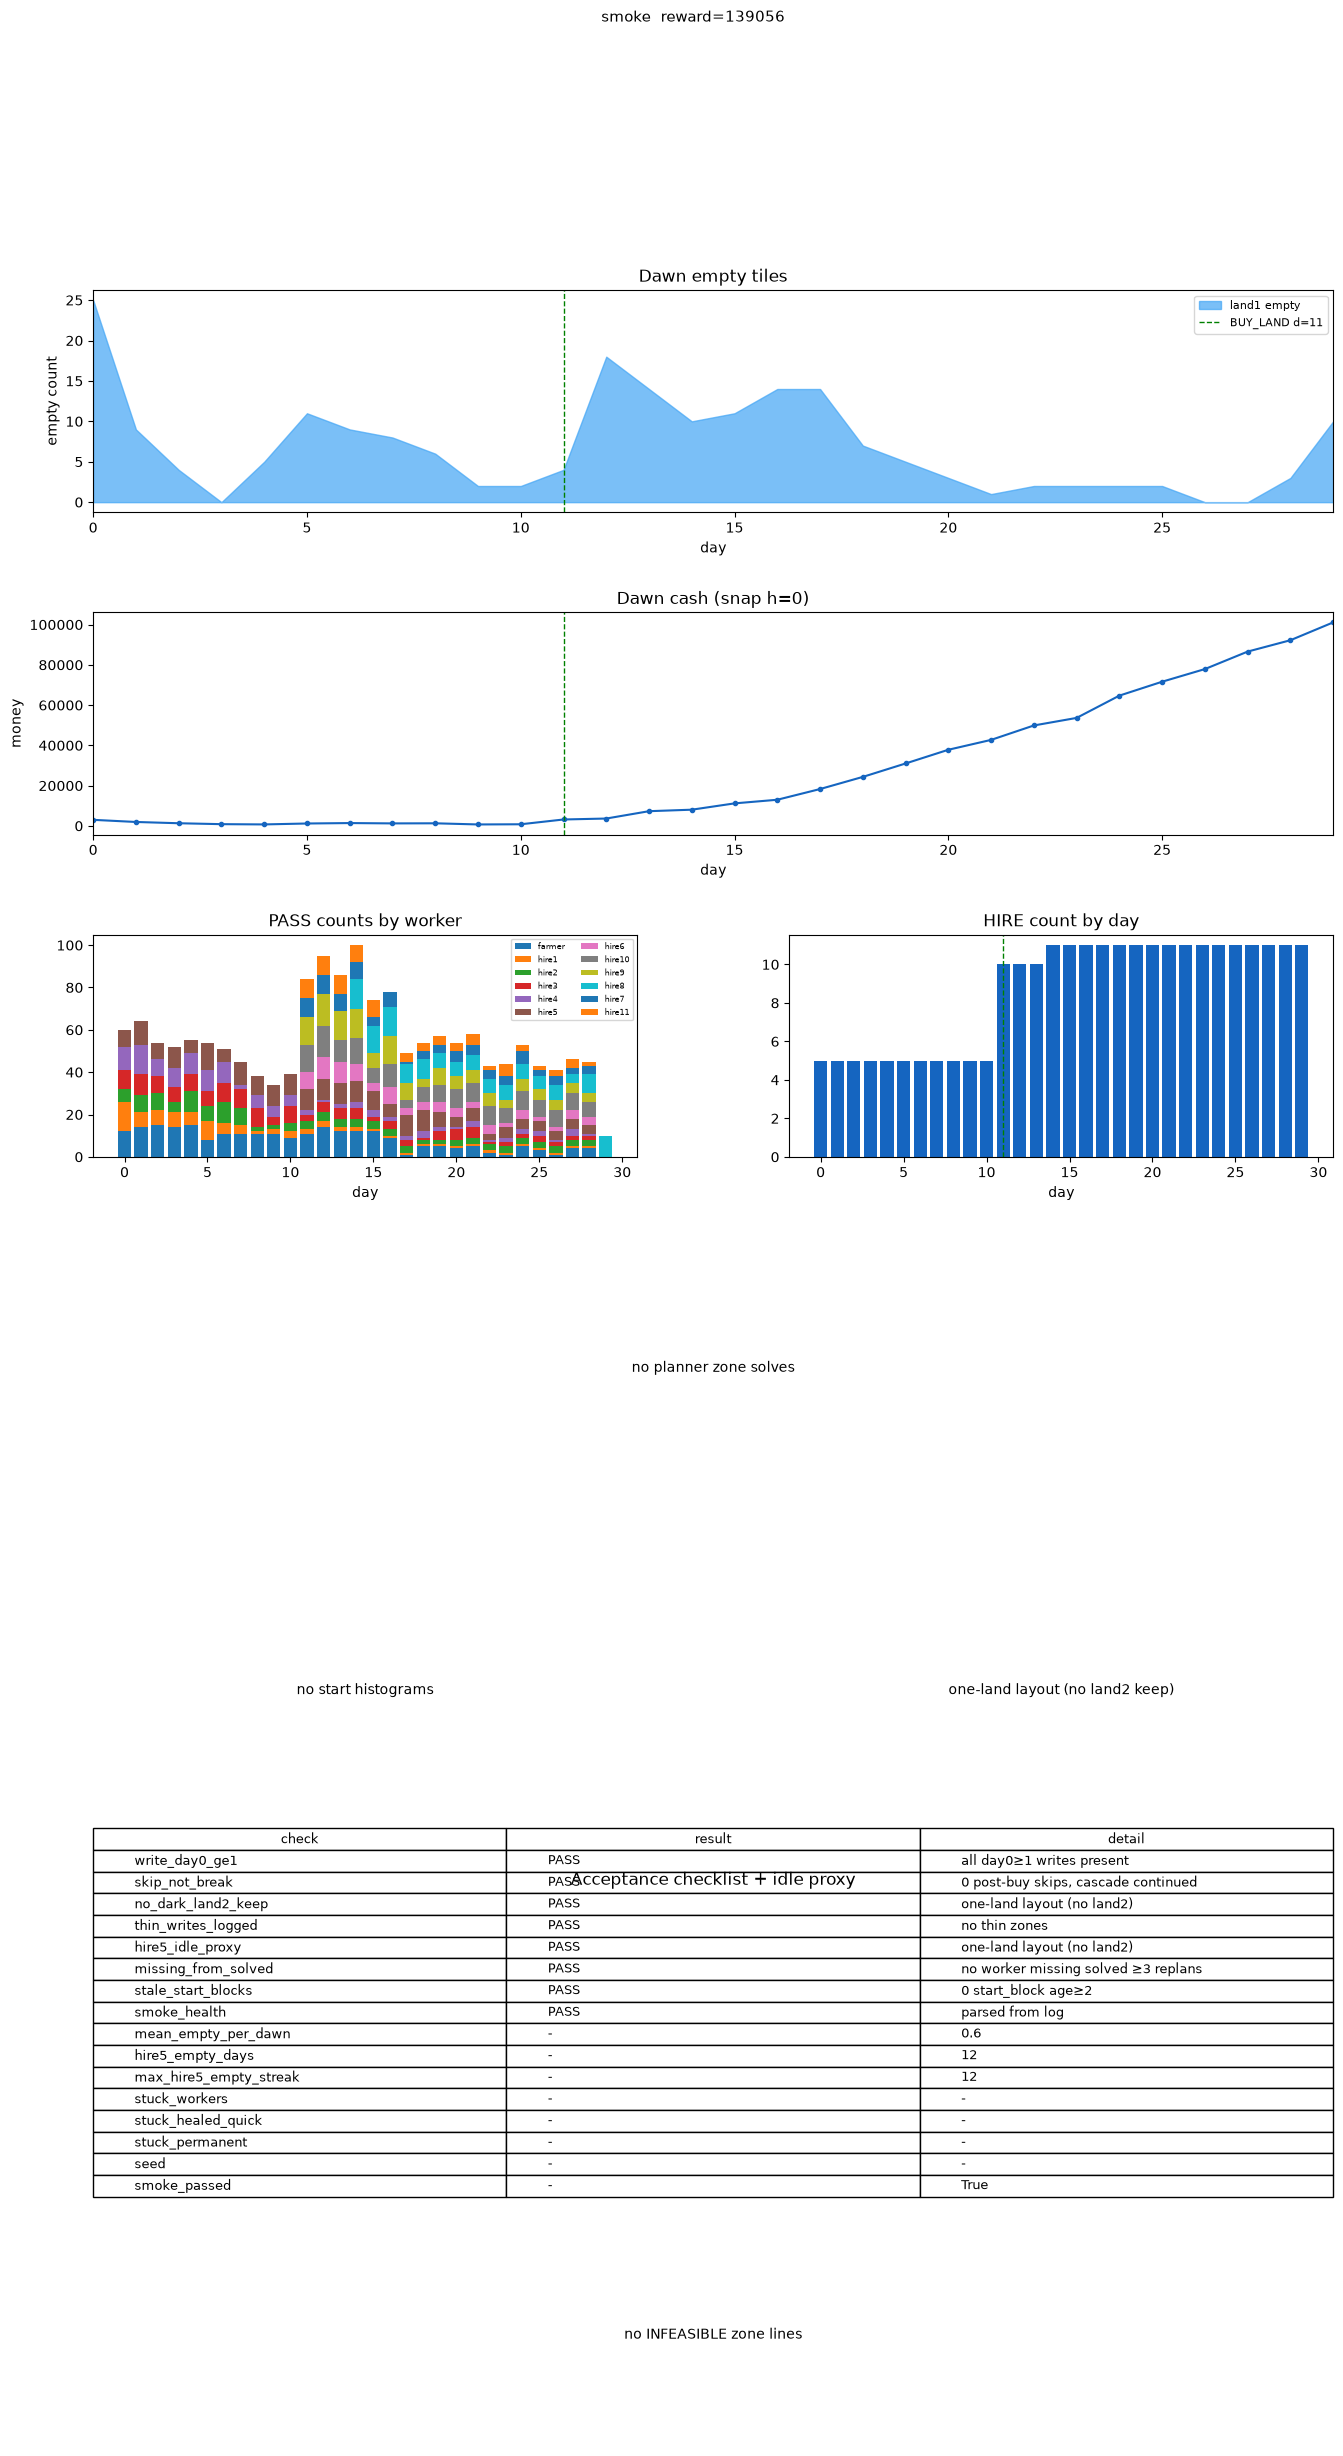

In [4]:
plot_smoke(report)

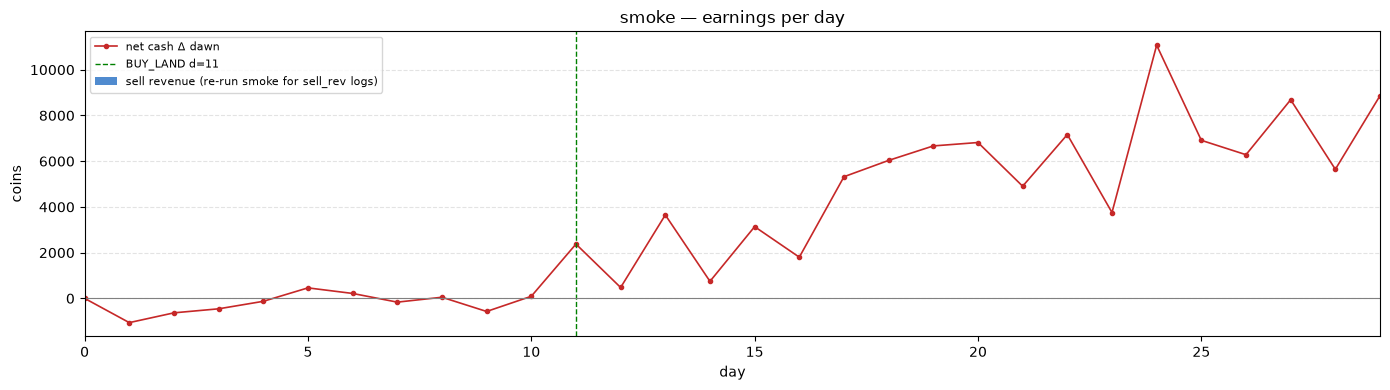

In [5]:
plot_earnings_by_day(report)

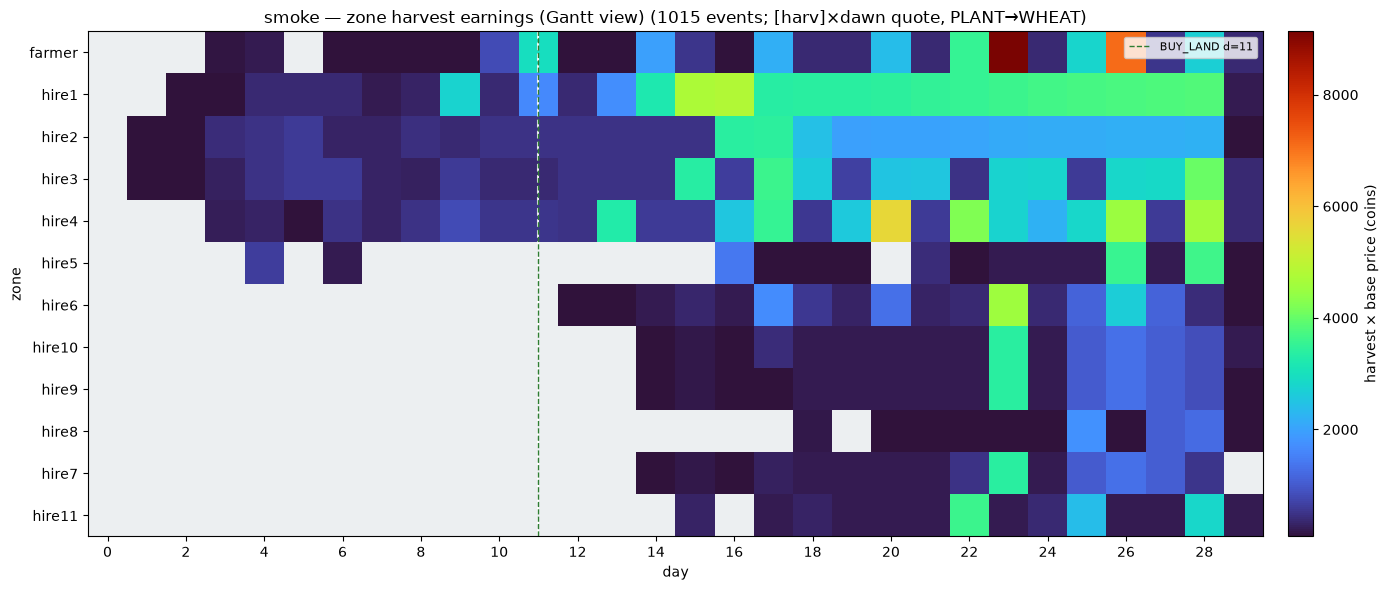

In [6]:
plot_earnings_by_zone(report)

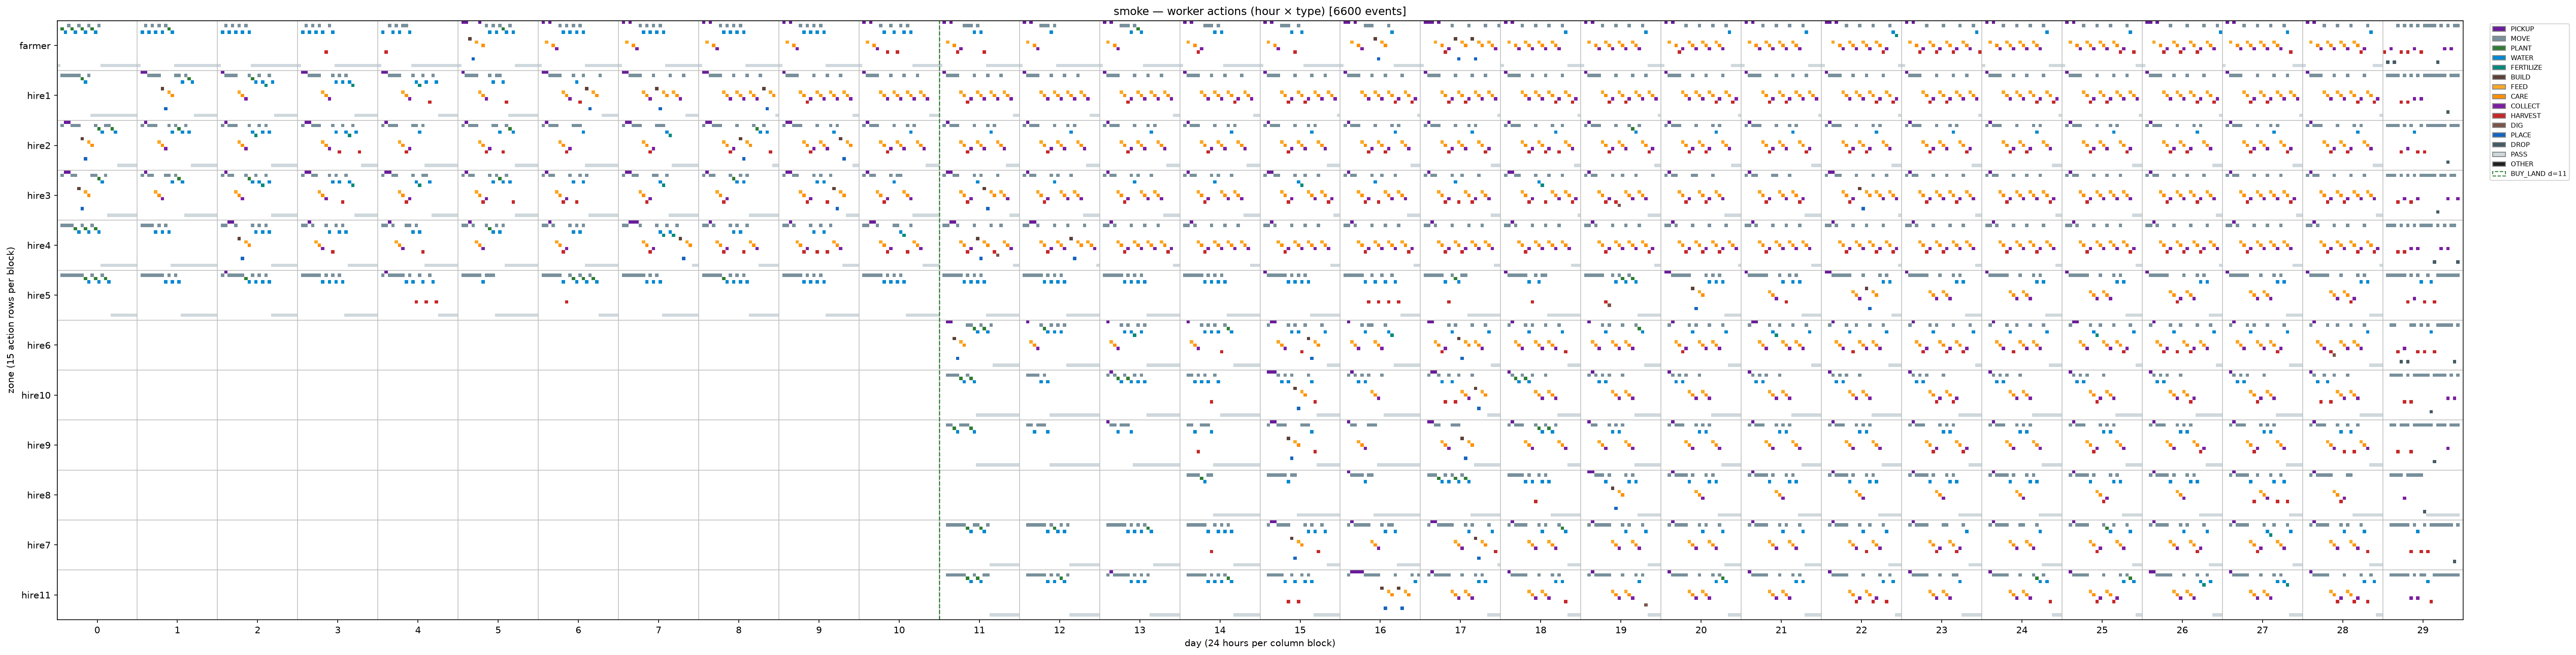

In [7]:
plot_worker_actions(report)

## Zone capacity (est_ops vs executed)

Stacked bars: tile ops + MOVE + PASS (+ reactive feed). Red dots = dawn dry-run `est_ops` (theo tile_ops); green dash = `net_tile_ops`.

After the plot: **per-day, per-tile** theo vs act action lists (mismatch tiles only).

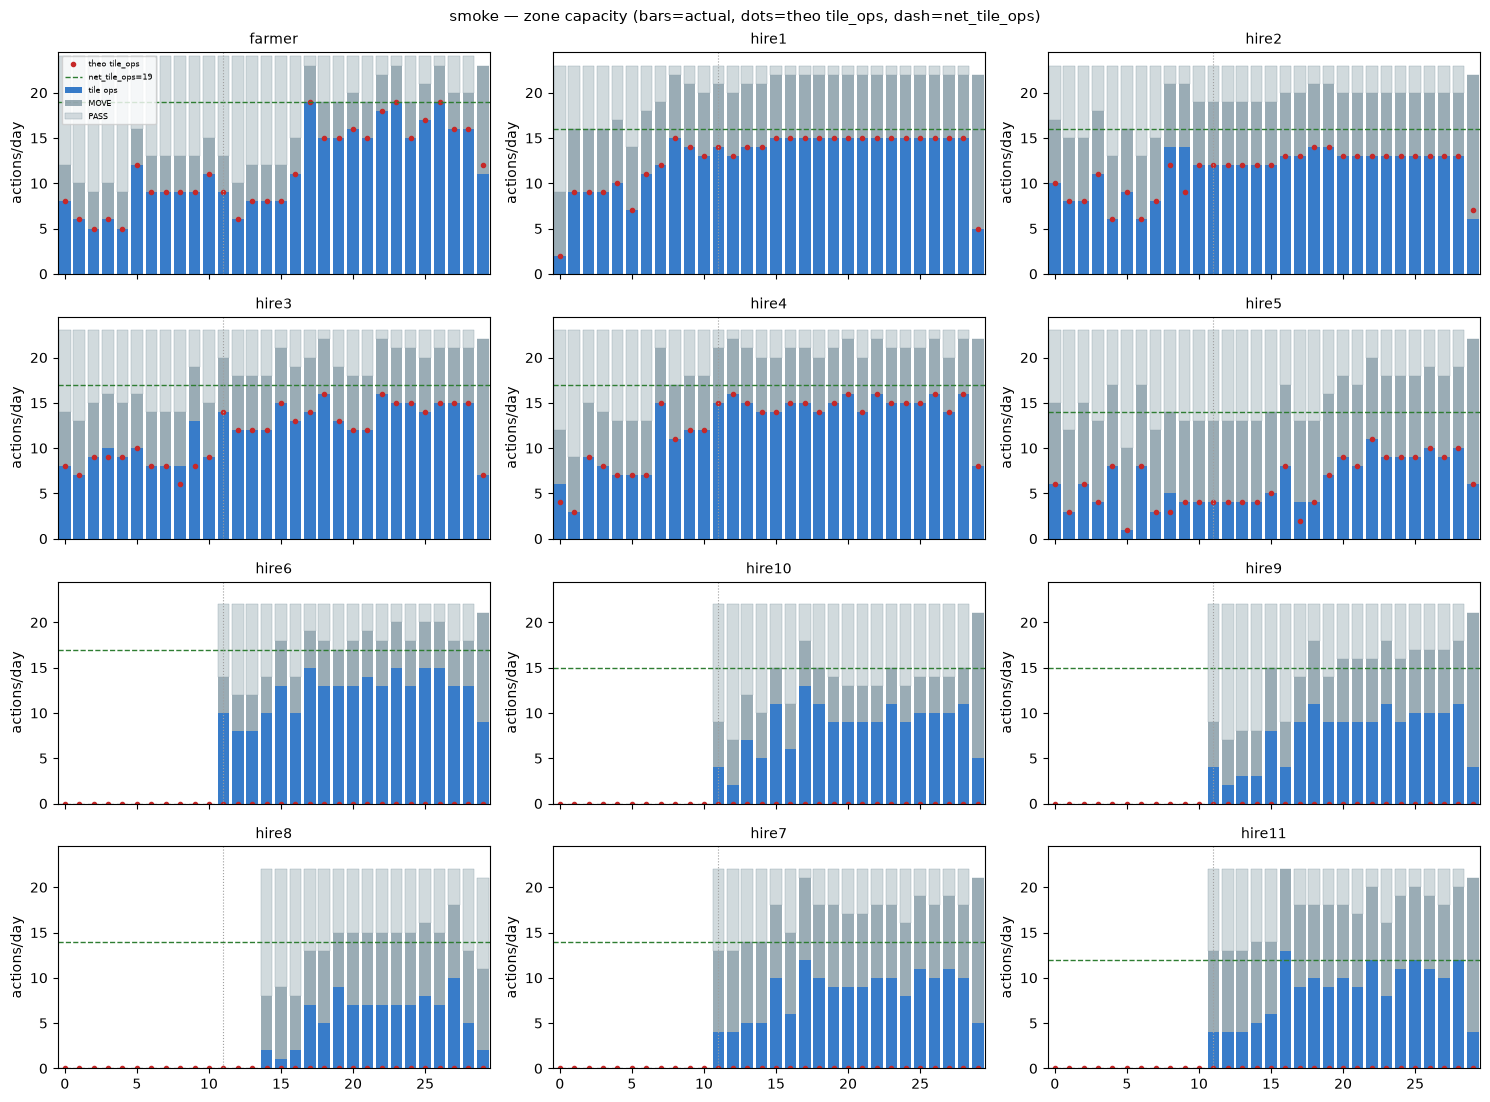

farmer: theo vs act (mismatch days only; matches chart tile_ops totals)
  d=29
    totals: theo=12 act=11 (on tiles: theo=8 act=8)
    shed theo: DROP DROP DROP DROP
    shed act:  DROP DROP DROP
hire1: theo vs act (mismatch days only; matches chart tile_ops totals)
  (all days match chart + tiles + shed)
hire2: theo vs act (mismatch days only; matches chart tile_ops totals)
  d=8
    totals: theo=12 act=14 (on tiles: theo=10 act=12)
    t13  theo: -
         act:  PLANT WATER
  d=9
    totals: theo=9 act=14 (on tiles: theo=8 act=12)
    shed theo: PICKUP
    shed act:  PICKUP PICKUP
    t14  theo: -
         act:  BUILD_PASTURE PLACE FEED CARE
  d=29
    totals: theo=7 act=6 (on tiles: theo=6 act=5)
    t11  theo: HARVEST COLLECT_FERTILIZER
         act:  HARVEST
hire3: theo vs act (mismatch days only; matches chart tile_ops totals)
  d=3
    totals: theo=9 act=10 (on tiles: theo=8 act=8)
    shed theo: PICKUP
    shed act:  PICKUP PICKUP
  d=8
    totals: theo=6 act=8 (on tiles: theo

In [8]:
plot_zone_capacity(report)

## Multi-run: stuck fires vs cascade skips

Diagnose ratchet vs skip-not-break from local stderr (not Kaggle replays).

```bash
SMOKE_RUNS=5 bash scripts/smoke_multi_run.sh   # -> scripts/smoke_runs/run_*.txt
```

- **Stuck fires rare** → ratchet unlikely the regressor; look at skip-not-break staffing thin/failing zones.
- **Skip frequency high** → N=3 ratchet may be too aggressive vs self-heal.

runs=5
reward: min=101007 max=129679 mean=110411 spread=28672 values=[102170, 118049, 101007, 129679, 101148]
stuck_fires: runs_with=3/5 mean=0.6 values=[0, 0, 1, 1, 1]
skip_cascade: mean=15.6 values=[10, 12, 16, 21, 19]
stuck_runs=3/5 stuck_worker_counts=[0, 0, 1, 1, 1]


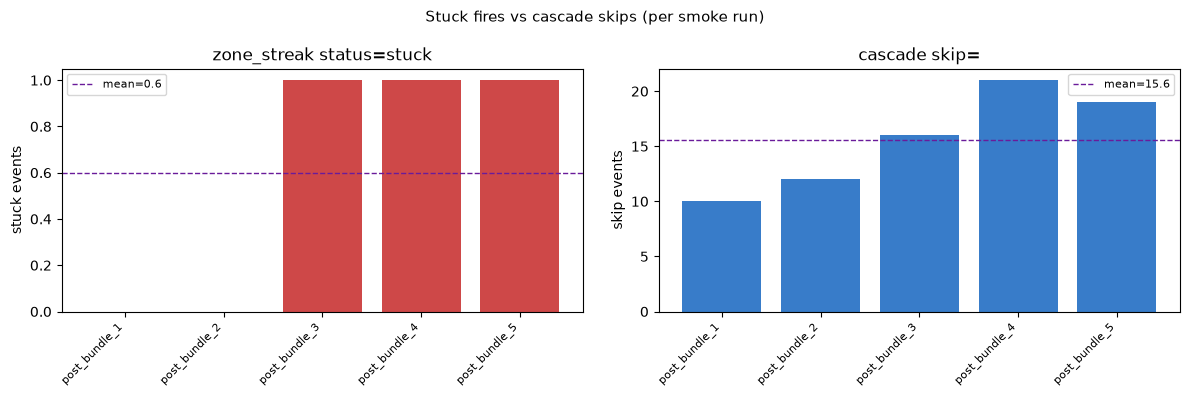

In [9]:
RUNS_DIR = ROOT / "scripts" / "smoke_runs"
run_logs = sorted(RUNS_DIR.glob("post_bundle_*.txt"))
if not run_logs:
    print(f"No logs in {RUNS_DIR} — run: SMOKE_RUNS=5 bash scripts/smoke_multi_run.sh")
else:
    reports = [analyze(p) for p in run_logs]
    print(summarize_distribution(reports))
    plot_stuck_skip_freq(reports)